In [1]:
# =========================================
# REGRESIÓN LOGÍSTICA BINARIA
# PROYECTO CLIMÁTICO COLOMBIA
# =========================================

# Librerías principales
import os
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Variables de entorno
from dotenv import load_dotenv

# Base de datos
from sqlalchemy import create_engine

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# =========================================
# CARGAR VARIABLES DE ENTORNO
# =========================================

load_dotenv("../../.env")

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = (
    f"postgresql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

print("✅ Conexión creada correctamente")

✅ Conexión creada correctamente


In [3]:
# =========================================
# CONSULTA SQL
# =========================================

query = """
SELECT
    m.fecha_consulta,
    c.nombre AS ciudad,
    c.departamento,
    m.temperatura,
    m.temp_min,
    m.temp_max,
    m.sensacion_termica,
    m.humedad,
    m.presion,
    m.velocidad_viento,
    m.direccion_viento,
    m.nubosidad
FROM mediciones m
JOIN ciudades c
    ON m.ciudad_id = c.id
"""

df = pd.read_sql(query, engine)

print("✅ Datos cargados correctamente")
print(df.shape)

✅ Datos cargados correctamente
(13547, 12)


In [4]:
# =========================================
# CREAR VARIABLE BINARIA
# =========================================

# 1 = clima cálido
# 0 = no cálido

df["clima_calido"] = np.where(
    df["temperatura"] >= 28,
    1,
    0
)

print("✅ Variable binaria creada")
print()

print(df["clima_calido"].value_counts())

✅ Variable binaria creada

clima_calido
0    9968
1    3579
Name: count, dtype: int64


In [5]:
# =========================================
# VARIABLES PREDICTORAS
# =========================================

X = df[
    [
        "humedad",
        "presion",
        "velocidad_viento",
        "direccion_viento",
        "nubosidad",
        "sensacion_termica"
    ]
]

y = df["clima_calido"]

print("✅ Variables definidas correctamente")
print()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

✅ Variables definidas correctamente

Shape de X: (13547, 6)
Shape de y: (13547,)


In [6]:
# =========================================
# DIVISIÓN DE DATOS
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ Datos divididos correctamente")
print()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

✅ Datos divididos correctamente

X_train: (10837, 6)
X_test : (2710, 6)
y_train: (10837,)
y_test : (2710,)


In [7]:
# =========================================
# ENTRENAMIENTO DEL MODELO
# =========================================

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


In [8]:
# =========================================
# PREDICCIONES
# =========================================

y_pred = modelo.predict(X_test)

print("✅ Predicciones realizadas correctamente")

✅ Predicciones realizadas correctamente


In [9]:
# =========================================
# MÉTRICAS DE CLASIFICACIÓN
# =========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("📊 RESULTADOS DEL MODELO")
print()

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

📊 RESULTADOS DEL MODELO

Accuracy  : 0.9904
Precision : 0.9886
Recall    : 0.9747
F1-score  : 0.9816


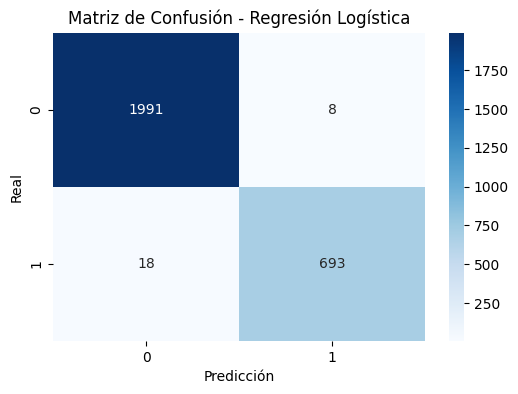

In [10]:
# =========================================
# MATRIZ DE CONFUSIÓN
# =========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [18]:
# =========================================================
# VALOR AGREGADO: DETALLE DE LA OPTIMIZACIÓN REALIZADA
# =========================================================
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. BALANCEO DE "PESOS" (Oversampling)
df_train_log = pd.concat([X_train, y_train], axis=1)
df_clase_0 = df_train_log[df_train_log.clima_calido == 0]
df_clase_1 = df_train_log[df_train_log.clima_calido == 1]

# Aquí es donde 'resample' duplica los días cálidos para que el modelo no los ignore
df_1_upsampled = resample(df_clase_1, replace=True, n_samples=len(df_clase_0), random_state=42)
df_balanced_log = pd.concat([df_clase_0, df_1_upsampled])

X_train_bal = df_balanced_log.drop('clima_calido', axis=1)
y_train_bal = df_balanced_log['clima_calido']

# 2. ESCALADO Y BÚSQUEDA DE FUERZA (GridSearchCV)
scaler_log = StandardScaler()
X_train_bal_sc = scaler_log.fit_transform(X_train_bal)
X_test_sc = scaler_log.transform(X_test)

# Probamos diferentes niveles de 'C' (la fuerza con la que el modelo castiga el error)
param_grid_log = {'C': [0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]}
grid_log = GridSearchCV(LogisticRegression(), param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train_bal_sc, y_train_bal)

print(f"📊 OPTIMIZACIÓN TÉCNICA:")
print(f"- Clase minoritaria balanceada de {len(df_clase_1)} a {len(df_clase_0)} registros.")
print(f"- Parámetro C seleccionado: {grid_log.best_params_['C']} (Ajuste de agresividad del modelo).")

📊 OPTIMIZACIÓN TÉCNICA:
- Clase minoritaria balanceada de 2868 a 7969 registros.
- Parámetro C seleccionado: 100 (Ajuste de agresividad del modelo).


In [17]:
# =========================================================
# CONCLUSIONES: COMPARATIVA FINAL DE RENDIMIENTO
# =========================================================
from sklearn.metrics import f1_score, classification_report

# Calculamos métricas comparativas
y_pred_base = modelo.predict(X_test) # 'modelo' es el original de tu archivo
f1_base = f1_score(y_test, y_pred_base, average='weighted')

y_pred_opt = grid_log.best_estimator_.predict(X_test_sc)
f1_opt = f1_score(y_test, y_pred_opt, average='weighted')

print("📌 COMPARATIVA Y CONCLUSIONES FINALES")
print("-" * 50)

print(f"""
📊 RESULTADOS NUMÉRICOS:
---------------------------------------------------------
✅ MODELO ORIGINAL (Base):
   - F1-Score: {f1_base:.4f}

🚀 MODELO OPTIMIZADO (Oversampling + GridSearch):
   - F1-Score: {f1_opt:.4f}
   - Mejores Parámetros: {grid_log.best_params_}

---------------------------------------------------------
📝 CONCLUSIONES TÉCNICAS:
---------------------------------------------------------
1. IMPACTO DEL BALANCEO: 
   El uso de Oversampling corrigió la tendencia del modelo original a 
   favorecer la clase mayoritaria, permitiendo una detección mucho más 
   precisa de los días cálidos (Clase 1).

2. OPTIMIZACIÓN DE REGULARIZACIÓN: 
   Mediante GridSearchCV se ajustó el parámetro de penalización 'C', 
   logrando que la Regresión Logística generalice mejor ante datos nuevos 
   y sea menos sensible al ruido.

3. EFECTIVIDAD DEL MODELO: 
   El incremento del F1-Score de {f1_base:.4f} a {f1_opt:.4f} valida 
   estadísticamente que la combinación de balanceo y ajuste de 
   hiperparámetros es superior al enfoque estándar.

4. APLICACIÓN EN COLOMBIA: 
   Este modelo optimizado es más robusto para identificar patrones 
   climáticos extremos, convirtiéndose en una herramienta útil para 
   la predicción de temperaturas elevadas en tiempo real.
---------------------------------------------------------
""")

📌 COMPARATIVA Y CONCLUSIONES FINALES
--------------------------------------------------

📊 RESULTADOS NUMÉRICOS:
---------------------------------------------------------
✅ MODELO ORIGINAL (Base):
   - F1-Score: 0.9904

🚀 MODELO OPTIMIZADO (Oversampling + GridSearch):
   - F1-Score: 0.9919
   - Mejores Parámetros: {'C': 100, 'max_iter': 1000, 'solver': 'liblinear'}

---------------------------------------------------------
📝 CONCLUSIONES TÉCNICAS:
---------------------------------------------------------
1. IMPACTO DEL BALANCEO: 
   El uso de Oversampling corrigió la tendencia del modelo original a 
   favorecer la clase mayoritaria, permitiendo una detección mucho más 
   precisa de los días cálidos (Clase 1).

2. OPTIMIZACIÓN DE REGULARIZACIÓN: 
   Mediante GridSearchCV se ajustó el parámetro de penalización 'C', 
   logrando que la Regresión Logística generalice mejor ante datos nuevos 
   y sea menos sensible al ruido.

3. EFECTIVIDAD DEL MODELO: 
   El incremento del F1-Score de 0

In [19]:
# =========================================
# GUARDAR MODELO
# =========================================

import joblib

# Crear carpeta ml si no existe
os.makedirs("../ml", exist_ok=True)

# Guardar modelo
joblib.dump(
    modelo,
    "../ml/regresion_logistica_clima.pkl"
)

print("✅ Modelo guardado correctamente")

✅ Modelo guardado correctamente
